# Parametros de Diseño del Fluxonium

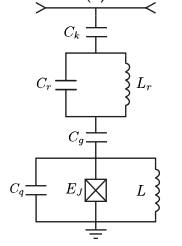

### Parametros de simulacion en QTCAD
- Ck = Resonator to line coupling capacitance fF
- Cr = Resonator capacitance fF
- Lr = Resonator inductance nH
- Cg = Coupling capacitance fF
- Cq = Qubit capacitance fF 
- Ec = Charging energy/2pi in GHz
- fr = Resonator frequency in GHz
- g = Coupling strength in MHz
### Parametros deseados de las JJs
- L = JJ Array Inductance nH
- Ej = Josephson energy/2pi in GHz
- El = Loss energy/2pi in GHz

In [1]:
from pathlib import Path
from collections import OrderedDict
import os
import sys

# Import Qiskit Metal.
import qiskit_metal as metal
from qiskit_metal import MetalGUI, Dict
from qiskit_metal import designs, draw
from qiskit_metal.qlibrary.core import QComponent
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.qubits.fluxonium_manucharyan import FluxoniumPocket
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.open_to_ground_v2 import OpenToGround
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond #bonding
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.terminations.ebeam_marker_v2 import Markers
from qiskit_metal.qlibrary.terminations.ebeam_frame import Frame

# Import the QTCAD renderer.
from qiskit_metal.renderers.renderer_qtcad.qtcad_renderer import QQTCADRenderer

## Energy functions

These functions calculate the energy of the fluxonium qubit based on its parameters. Please check units before using them.

In [2]:
from scipy.constants import c, e, hbar
from scipy.constants import physical_constants as pc
import numpy as np

varphi_0 = pc['mag. flux quantum'][0]/ (2*np.pi) # in Wb

get_EC = lambda C_sigma: e**2 / (2*C_sigma*1e-6 * hbar * 2*np.pi) # in GHz, C_sigma in fF  OK!
get_EJ = lambda I0: I0 * varphi_0 / (2*np.pi*hbar) *1e-18 # I0 in nA and varphi_0 in Wb OK!
get_EL = lambda L: varphi_0**2 / (L*2*np.pi*hbar) # in GHz, L in nH  OK!

# for lambda/2 resonator (open)
get_Cr_ol2 = lambda f_0, Z0: np.pi / (2 * 2*np.pi*f_0 * Z0)*1e6 # in fF, omega_0 in GHz, Z0 in Ohm  OK!
get_Lr_ol2 = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6 # in nH, omega_0 in GHz, Cr in fF    OK!

#for lambda/4 resonator
get_Cr_sl4 = lambda f_0, Z0: np.pi / (4 * 2*np.pi*f_0 * Z0)*1e6 # in fF, omega_0 in GHz, Z0 in Ohm  OK!
get_Lr_sl4 = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6 # in nH, omega_0 in GHz, Cr in fF    OK!

# coupling coef
# get_g = lambda Cg, C_sigma, Cr, Zr: 2*e * Cg *1e15/ (C_sigma * Cr) * np.sqrt(hbar / (2*Zr)) / (2*np.pi*hbar) * 1e-6 # OK! 
get_g = lambda Cg, C_sigma, Cr, Zr: 2*e * Cg *1e15/ (C_sigma * Cr) * np.sqrt(hbar / (2*Zr)) / (2*np.pi*hbar) * 1e-6 # OK!
# resonator_len
res_len_lambda_2 = lambda eff, f: c/(2*np.sqrt(eff)*f)*1e3 # in mm
res_len_lambda_4 = lambda eff, f: c/(4*np.sqrt(eff)*f)*1e3 # in mm

# Simulación de los modos de resonancia de los qubits

In [3]:
# Each time you create a new quantum circuit design,
# you start by instantiating a QDesign class.

design = designs.MultiPlanar({}, True)
design.chips.main.material = 'silicon'
design.variables['cpw_width'] = '15 um'  # ancho de la linea coplanar
design.variables['cpw_gap'] = '8.733 um' # gap de la linea coplanar, para 50 ohmios
design._chips['main']['size']['size_x'] = '10mm'
design._chips['main']['size']['size_y'] = '3mm'
design._chips['main']['size']['size_z'] = '-525um' #espesor waffer
design._chips['main']['size']['center_x'] = '0mm'
design._chips['main']['size']['center_y'] = '0mm'

gui = MetalGUI(design)

### QUBIT

In [12]:
## QUBIT
from qiskit_metal.qlibrary.qubits.fluxonium import FluxoniumPocket

# Q1 details
options = dict(chip='main', nanowire = False, 
              orientation = 90, pos_x = '3.5mm', pos_y = '0.5mm',
              gds_cell_name='junction_0',
              gds_cell_inductor='jj_array0' ,
              inductor_orientation='-1', 
              flux_bias_line_options=Dict(make_fbl = True, cpw_width = design.variables['cpw_width'], cpw_gap = design.variables['cpw_gap']),              
              charge_line_options=Dict(loc_H = +1, make_cl = False,),
              readout_line_options=Dict(loc_H = +1, make_rol = True,),
              jj_inductance=False,
                )
               
q1 = FluxoniumPocket(design,'Q1', options = dict(**options))

gui.rebuild()
gui.autoscale()

### RESONADOR

In [13]:
## Estimation for the resonator length
eff=(11.9+1)/2 ## Si and Air
f=6e9  # Resonator frequency in Hz
jogs = OrderedDict()
jogs[0] = ["L", '448um']
jogs[1] = ["R", '400um']
jogs[2] = ["R", '100um']
l = res_len_lambda_4(eff, f)  # in mm
# Correccion debido al acoplamiento capacitivo con el qubit, que hace que la frecuencia de resonancia del modo sea menor a la esperada
f_sim = 5.175645e9                     # Hz - frecuencia simulada con acoplamiento
v_ph = 4 * l * f                       # Velocidad de fase
L_eff = v_ph / (4 * f_sim)             # Longitud efectiva vista por el modo a f_sim
delta_L_cap = L_eff - l                # Longitud eléctrica añadida por la capacitancia
L_new = (v_ph / (4 * f)) - delta_L_cap # Nueva longitud física para compensar

# Primero usar esta longitud sin corregir, para ver el efecto del acoplamiento capacitivo en la frecuencia de resonancia del modo
#total_length = f'{l}mm'
# Luego usar la longitud corregida para compensar el efecto del acoplamiento capacitivo y ver si la frecuencia de resonancia del modo se acerca más a la esperada
total_length = f'{L_new}mm'

stg1 = ShortToGround(design, "stg1", options=Dict(chip='main', pos_x='2.6mm',  pos_y='1.2mm', orientation='180'))

# Resonador conectado al pin de readout del Qubit
opt_meander = Dict(
    trace_width= design.variables['cpw_width'] ,
    trace_gap= design.variables['cpw_gap'] ,
    meander=Dict(
        spacing= '102um',
        asymmetry= '0um'),    
    total_length= total_length,
    fillet = '50um',
    pin_inputs=Dict(
        end_pin=Dict(
            component= 'Q1',
            pin= 'readout_line'),
        start_pin=Dict(
            component= 'stg1',
            pin= 'short')),
    lead=Dict(
        start_straight='0.02mm',
        end_straight='0.1mm',
        end_jogged_extension=jogs
        ),
)

meandro_1 = RouteMeander(design, 'meandro_1',  options=opt_meander)

# rebuild the GUI
gui.rebuild()
gui.autoscale()

### SIMULACIÓN

In [14]:
# Directories and file paths.
device_name = "chip_fluxonium"
# Work in the outputs folder of the current directory.
output_dir = str(Path.cwd() / "output" / device_name)
# Geometry XAO file required for adaptive meshing.
geo_filepath = output_dir + "/" + device_name + ".xao"
# Mesh file.
mesh_filepath = output_dir + "/" + device_name + ".msh4"

# Whether to calculate the capacitance matrix using adaptive meshing.
adaptive = True
# Set minimum and maximum characteristic lengths for the mesh elements.
mesh_h_min = "150um"
mesh_h_max = "300um"
# Number of Maxwell eigenmodes.
num_modes = 1

# Setting up the solver
qtcad_renderer = QQTCADRenderer(
    design,
    options=dict(
        adaptive=adaptive,
        output_dir=output_dir,
        mesh_scale=1e-3,
        adaptive_mesh_scale=1e-3,
        geo_filepath=geo_filepath,
        mesh_filepath=mesh_filepath,
        make_subdir=False,
        box_plus_buffer=True,        # Usar bbox del diseño + buffer
        buffer_distance='300um',
        maxwell_emode=dict(
            num_modes=num_modes,
            tol_rel=0.1,
        ),
    ),
)

open_pins = [("Q1", "readout_line")]

# Create the geometry from the design.
qtcad_renderer.render_design(
    selection=['stg1','Q1','meandro_1'],
    open_pins=open_pins,
    # Do not mesh the device (yet).
    mesh_geoms=False,
    initial_mesh_h_min=mesh_h_min,
    initial_mesh_h_max=mesh_h_max,
)

Info    : Clearing all models and views...
Info    : Done clearing all models and views


In [15]:
# Mesh the device.
qtcad_renderer.gmsh.add_mesh(dim=3, intelli_mesh=adaptive)
# Export the geometry and mesh files.
file_mesh, file_geo = qtcad_renderer.export_mesh()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 1087 (Line)
Info    : [ 10%] Meshing curve 1088 (Line)
Info    : [ 10%] Meshing curve 1089 (Line)
Info    : [ 10%] Meshing curve 1090 (Line)
Info    : [ 10%] Meshing curve 1091 (Line)
Info    : [ 10%] Meshing curve 1092 (Line)
Info    : [ 10%] Meshing curve 1093 (Line)
Info    : [ 10%] Meshing curve 1094 (Line)
Info    : [ 10%] Meshing curve 1095 (Line)
Info    : [ 10%] Meshing curve 1096 (Line)
Info    : [ 10%] Meshing curve 1097 (Line)
Info    : [ 10%] Mes

02:29PM 29s WARNING [export_geometry]: WARNING: The existing model contains mesh size field definitions, which are not needed when exporting to XAO files for use in renderers that support adaptive meshing refinement (AMR). If you are going to use AMR, consider disabling the use of mesh size fields.


Info    : Improving       8726 tet. on   1 thrd (S & ER)
Info    :  	Final tet. mesh contains 13862 tetrahedra
Info    :  	Final tet. mesh contains 2701 vertices
Info    : tEmptyMesh  	 = 	    0.012
Info    : tVerifyBnd  	 = 	    0.001
Info    : tBndRecovery	 = 	    0.014
Info    : tConvertMesh	 = 	    0.001
Info    : tRefine     	 = 	    0.067
Info    : tOptimize   	 = 	    7.195
Info    : Done meshing 3D (Wall 7.29454s, CPU 7.30112s)
Info    : 2745 nodes 22263 elements
Info    : Writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.xao'...
Info    : Done writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.xao'
Info    : Writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.msh4'...
Info    : Done writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.msh4'


In [16]:
import os
os.environ["QTCAD_LICENSE_PATH"] = "/Users/leubiedo/Documents/QuantumCircuits/qtcad-2/license.lic"
# Export parameters.
qtcad_renderer.export_parameters()
# Run QTCAD to extract the Maxwell eigenmodes.
qtcad_renderer.run_qtcad("eigs",env_name="qtcad-2.2.2")

02:29PM 31s INFO [run_qtcad]: =================
02:29PM 31s INFO [run_qtcad]: Running QTCAD®...
02:29PM 31s INFO [run_qtcad]: =================


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   
                                 Version 2.2.2                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   
      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      
                        For documentation, please visit:                        
                      https://doc

![image.png](/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/resonador1.png)

In [17]:
frequencies = qtcad_renderer.load_qtcad_maxwell_eigenmodes()
print(frequencies)

           Frequency (GHz)
Eigenmode                 
0                 6.007208


In [18]:
# frecuencias de resonancia
fr_1 = frequencies.iloc[0, 0]
# capactitancias e inductancias de los resonadores
Z0 = 50
Cr_1 = get_Cr_sl4(fr_1, Z0)
Lr_1 = get_Lr_sl4(fr_1, Cr_1)

print(f"Resonator 1: fr = {fr_1:.3f} GHz, Cr = {Cr_1:.3f} fF, Lr = {Lr_1:.3f} nH")

Resonator 1: fr = 6.007 GHz, Cr = 416.167 fF, Lr = 1.687 nH


# Simulación de la matriz de capacitancia (Resonador + TL)

In [3]:
# Each time you create a new quantum circuit design,
# you start by instantiating a QDesign class.

design = designs.MultiPlanar({}, True)
design.chips.main.material = 'silicon'
design.variables['cpw_width'] = '15 um'  # ancho de la linea coplanar
design.variables['cpw_gap'] = '8.733 um' # gap de la linea coplanar, para 50 ohmios
design._chips['main']['size']['size_x'] = '10mm'
design._chips['main']['size']['size_y'] = '3mm'
design._chips['main']['size']['size_z'] = '-525um' #espesor waffer
design._chips['main']['size']['center_x'] = '0mm'
design._chips['main']['size']['center_y'] = '0mm'

gui = MetalGUI(design)

## LÍNEA DE TRANSMISIÓN

In [4]:
#Setup the launchpad1 location and orientation
## Read In launch pad
launch_options = dict(chip='main', pos_x='-4.00mm', pos_y='0mm', orientation='0',
                      lead_length='30um', pad_width='250um',
                      pad_height='400um', pad_gap='150um', taper_height='350um',
                     )
lp = LaunchpadWirebond(design, 'LPReadIn', options = launch_options)

# Read Out launch pad
launch_options = dict(chip='main', pos_x='4.00mm', pos_y='0mm', orientation='180',
                      lead_length='30um', pad_width='250um',
                       pad_height='400um', pad_gap='150um', taper_height='350um',
                     )
lp = LaunchpadWirebond(design, 'LPReadOut', options = launch_options)

Transmission_Line = {'pin_inputs':
           {'start_pin': {'component': 'LPReadIn', 'pin': 'tie'},
             'end_pin': {'component': 'LPReadOut', 'pin': 'tie'}},
            'lead': {'start_straight': '3970um', 'end_straight': '3970um',
                    }, 
                    'total_length': '8mm', 'fillet': "90um"
            }

TransLine = RoutePathfinder(design, 'TL', Transmission_Line)

gui.rebuild()
gui.autoscale()

## QUBIT

In [5]:
## QUBIT
from qiskit_metal.qlibrary.qubits.fluxonium import FluxoniumPocket

# Q1 details
options = dict(chip='main', nanowire = False, 
              orientation = 90, pos_x = '3.5mm', pos_y = '0.5mm',
              gds_cell_name='junction_0',
              gds_cell_inductor='jj_array0' ,
              inductor_orientation='-1', 
              flux_bias_line_options=Dict(make_fbl = True, cpw_width = design.variables['cpw_width'], cpw_gap = design.variables['cpw_gap']),              
              charge_line_options=Dict(loc_H = +1, make_cl = False,),
              readout_line_options=Dict(loc_H = +1, make_rol = True,),
              jj_inductance=False,
                )
               
q1 = FluxoniumPocket(design,'Q1', options = dict(**options))

gui.rebuild()
gui.autoscale()

## RESONADOR

In [6]:
## Estimation for the resonator length
eff=(11.9+1)/2 ## Si and Air
f=6e9  # Resonator frequency in Hz
jogs = OrderedDict()
jogs[0] = ["L", '448um']
jogs[1] = ["R", '400um']
jogs[2] = ["R", '100um']
l = res_len_lambda_4(eff, f)  # in mm
# Correccion debido al acoplamiento capacitivo con el qubit, que hace que la frecuencia de resonancia del modo sea menor a la esperada
f_sim = 5.175645e9                     # Hz - frecuencia simulada con acoplamiento
v_ph = 4 * l * f                       # Velocidad de fase
L_eff = v_ph / (4 * f_sim)             # Longitud efectiva vista por el modo a f_sim
delta_L_cap = L_eff - l                # Longitud eléctrica añadida por la capacitancia
L_new = (v_ph / (4 * f)) - delta_L_cap # Nueva longitud física para compensar

# Primero usar esta longitud sin corregir, para ver el efecto del acoplamiento capacitivo en la frecuencia de resonancia del modo
#total_length = f'{l}mm'
# Luego usar la longitud corregida para compensar el efecto del acoplamiento capacitivo y ver si la frecuencia de resonancia del modo se acerca más a la esperada
total_length = f'{L_new}mm'

otg1 = OpenToGround(design, "otg1", options=Dict(chip='main', pos_x='2.6mm',  pos_y='1.2mm', orientation='180'))

# Resonador conectado al pin de readout del Qubit
opt_meander = Dict(
    trace_width= design.variables['cpw_width'] ,
    trace_gap= design.variables['cpw_gap'] ,
    meander=Dict(
        spacing= '102um',
        asymmetry= '0um'),    
    total_length= total_length,
    fillet = '50um',
    pin_inputs=Dict(
        end_pin=Dict(
            component= 'Q1',
            pin= 'readout_line'),
        start_pin=Dict(
            component= 'otg1',
            pin= 'open')),
    lead=Dict(
        start_straight='0.02mm',
        end_straight='0.1mm',
        end_jogged_extension=jogs
        ),
)

meandro_1 = RouteMeander(design, 'meandro_1',  options=opt_meander)

# rebuild the GUI
gui.rebuild()
gui.autoscale()

## SIMULACIÓN

In [7]:
# Directories and file paths.
device_name = "chip_fluxonium"
# Work in the outputs folder of the current directory.
output_dir = str(Path.cwd() / "output" / device_name)
# Geometry XAO file required for adaptive meshing.
geo_filepath = output_dir + "/" + device_name + ".xao"
# Mesh file.
mesh_filepath = output_dir + "/" + device_name + ".msh4"

# Whether to calculate the capacitance matrix using adaptive meshing.
adaptive = True
# Set minimum and maximum characteristic lengths for the mesh elements.
mesh_h_min = "200um"
mesh_h_max = "300um"

# Setting up the solver
qtcad_renderer = QQTCADRenderer(
    design,
    options=dict(
        adaptive=True,
        output_dir=output_dir,
        mesh_scale=1e-3,
        adaptive_mesh_scale=1e-3,
        geo_filepath=geo_filepath,
        mesh_filepath=mesh_filepath,
        make_subdir=False,
        capacitance=dict(           # <- ahora importa el bloque capacitance, no maxwell_emode
            tol_rel=0.5,
            tol_abs=0.1,
            min_converged_iters=3,
        ),
    ),
)

open_pins = [
    ("otg1", "open"),
    ("LPReadIn", "tie"),
    ("LPReadOut", "tie"),
]

# Create the geometry from the design.
qtcad_renderer.render_design(
    selection=['meandro_1', 'TL', 'LPReadIn', 'LPReadOut', 'Q1', 'otg1'],
    open_pins=open_pins,
    skip_junctions=True,
    mesh_geoms=False,
    initial_mesh_h_min="150um",
    initial_mesh_h_max="300um",
)

Info    : Clearing all models and views...
Info    : Done clearing all models and views


In [8]:
import os
os.environ["QTCAD_LICENSE_PATH"] = "/Users/leubiedo/Documents/QuantumCircuits/qtcad-2/license.lic"
qtcad_renderer.gmsh.add_mesh(dim=3, intelli_mesh=True)
qtcad_renderer.export_mesh()
qtcad_renderer.export_parameters()
qtcad_renderer.run_qtcad("cap", env_name="qtcad-2.2.2")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 673 (Line)
Info    : [ 10%] Meshing curve 674 (Line)
Info    : [ 10%] Meshing curve 675 (Line)
Info    : [ 10%] Meshing curve 676 (Line)
Info    : [ 10%] Meshing curve 677 (Line)
Info    : [ 10%] Meshing curve 678 (Line)
Info    : [ 10%] Meshing curve 679 (Line)
Info    : [ 10%] Meshing curve 680 (Line)
Info    : [ 10%] Meshing curve 681 (Line)
Info    : [ 10%] Meshing curve 682 (Line)
Info    : [ 10%] Meshing curve 683 (Line)
Info    : [ 10%] Meshing curve 684 (Line)
Info    : [ 10%] Meshing curve 685 (Line)
Info    : [ 10%] Meshing curve 686 (Line)
Info    : [ 10%] Meshing curve 687 (Line)
Info    : [ 10%] Meshing curve 688 (Line)
Info    : [ 10%] Meshing curve 689 (Line)
Info    : [ 10%] Meshing curve 690 (Line)
Info    : [ 10%] Meshing curve 691 (Line)
Info    : [ 10%] Meshing curve 692 (Line)
Info    : [ 10%] Meshing curve 693 (Line)
Info    : [ 10%] Meshing curve 694 (Line)
Info    : [ 10%] Meshing curve 695 (Line)
Info    : 

10:22AM 23s WARNING [export_geometry]: WARNING: The existing model contains mesh size field definitions, which are not needed when exporting to XAO files for use in renderers that support adaptive meshing refinement (AMR). If you are going to use AMR, consider disabling the use of mesh size fields.


Info    : Improving      13567 tet. on   1 thrd (S & ER)
Info    :  	Final tet. mesh contains 33139 tetrahedra
Info    :  	Final tet. mesh contains 6195 vertices
Info    : tEmptyMesh  	 = 	    0.020
Info    : tVerifyBnd  	 = 	    0.002
Info    : tBndRecovery	 = 	    0.025
Info    : tConvertMesh	 = 	    0.002
Info    : tRefine     	 = 	    0.090
Info    : tOptimize   	 = 	   10.297
Info    : Done meshing 3D (Wall 10.4465s, CPU 10.4108s)
Info    : 6239 nodes 46656 elements
Info    : Writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.xao'...
Info    : Done writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.xao'
Info    : Writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.msh4'...
Info    : Done writing '/Users/leubiedo/Documents/QuantumCircuits/Junturas/Designs/output/chip_fluxonium/chip_fluxonium.msh4'


10:22AM 24s INFO [run_qtcad]: =================
10:22AM 24s INFO [run_qtcad]: Running QTCAD®...
10:22AM 24s INFO [run_qtcad]: =================


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   
                                 Version 2.2.2                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   
      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      
                        For documentation, please visit:                        
                      https://doc

In [9]:
capacitance_matrix = qtcad_renderer.load_qtcad_capacitance_matrix()
capacitance_matrix

,LPReadOut_launch_pad,Q1_readout_padNline,Q1_pad_top,Q1_pad_bot,ground_plane
LPReadOut_launch_pad,1756.722016,-4.365628,-0.517253,-0.645064,-1728.693960
Q1_readout_padNline,-4.365628,908.952669,-5.132253,-0.907553,-896.990823
Q1_pad_top,-0.517253,-5.132253,35.682149,-3.185186,-26.390717
Q1_pad_bot,-0.645064,-0.907553,-3.185186,35.745150,-30.477648
ground_plane,-1728.693960,-896.990823,-26.390717,-30.477648,2657.510187


Capacitancia entre Linea de Transmisión y el Resonador indica el factor de perdida de fotones desde la LT al resonador.
$$\kappa = \frac{\omega_r^2\,C_k^2\,Z_0}{C_r}$$

In [91]:
Ck_1 = np.abs(capacitance_matrix.iloc[0,1])*1e-15 #F
fr_1 = 6.007208e9 #Hz
wr_1 = 2*np.pi*fr_1 #rad/s
kappa = (wr_1**2 * Ck_1**2 * 50) / Cr      # todo en SI -> rad/s
kappa_Hz = kappa / (2*np.pi)              # ancho de linea en Hz
print(f"Ck_1 = {Ck_1:.3f} fF, fr_1 = {fr_1*1e-9:.3f} GHz, kappa_1 = {kappa_Hz*1e-3:.3f} KHz")

Ck_1 = 0.000 fF, fr_1 = 6.007 GHz, kappa_1 = 519.184 KHz


La capacitancia del pad_top a masa, esta en paralelo con la capacitancia del pad_top al resonador y en paralelo tambien con la capacitancia del pad_top a la linea de transmisión. Esta suma la denomino $C_T$, lo mismo ocurre con el pad_bot y la capacitancia resultante la denomino $C_B$. $C_T$ y $C_B$ estan en serie y ambas en paralelo con la capacitancia entre pad_top y pad_bot ($C_{TB}$), por lo que la capacitancia del qubit $C_q$ es:
$$
C_q = C_{TB} + \frac{C_T\cdot C_B}{C_T + C_B}
$$

In [40]:
c_top_to_ground = abs(capacitance_matrix.iloc[2,4]) #fF
c_top_to_res = abs(capacitance_matrix.iloc[2,1]) #fF
c_top_to_TL = abs(capacitance_matrix.iloc[2,0]) #fF
CT = c_top_to_ground + c_top_to_res + c_top_to_TL

c_bot_to_ground = abs(capacitance_matrix.iloc[3,4]) #fF
c_bot_to_res = abs(capacitance_matrix.iloc[3,1]) #fF
c_bot_to_TL = abs(capacitance_matrix.iloc[3,0]) #fF
CB = c_bot_to_ground + c_bot_to_res + c_bot_to_TL

CTB = abs(capacitance_matrix.iloc[2,3]) #fF

Cq = CTB + ((CT * CB)/(CT + CB)) #fF
Ec = get_EC(Cq) #GHz

print(f"Cq = {Cq:.3f} fF, Ec = {Ec:.3f} GHz")

Cq = 19.203 fF, Ec = 1.009 GHz


La capacitancia del pad_top al resonador es $C_{TR}$ mientras que la del pad_bot al resonador es $C_{BR}$, a su vez, la capacitancia del pad_top a masa es $C_{TG}$ mientras que la del pad_bot a masa es $C_{BG}$, por lo que la capacitancia del acoplamiento entre el resonador y el qubit, $C_g$ es tal que:
$$
C_g = \frac{C_{TR}C_{BG} - C_{BR}C_{BG}}{C_{T}+C_{B}}
$$

In [42]:
Cg = (c_top_to_res * c_bot_to_ground - c_bot_to_res * c_top_to_ground) / (CT + CB)
print(f"Cg = {Cg:.3f} fF")

Cg = 2.068 fF


Impedancia del resonador ($Z_r$):
$$
Z_r = \sqrt{\frac{L_r}{C_r}}
$$

In [47]:
Cr = 416.167*1e-15 #F
Lr = 1.687*1e-9 #H
Zr = np.sqrt(Lr/Cr) #Ohm
print(f"Zr = {Zr:.3f} Ohm")

Zr = 63.668 Ohm


El factor de acoplamiento $g$ se calcula como:
$$
\frac{g}{2\pi} = \frac{2e}{h}\frac{C_g}{C_q C_r}\sqrt{\frac{\hbar}{2Z_r}}|\langle 0|\hat{n}|1\rangle|
$$

In [58]:
import numpy as np
from scipy.constants import e, h, hbar

PHI0_OVER_2PI = hbar / (2 * e)   # Phi_0 / 2pi

# --- conversiones desde la sim (capacitancia + inductancias) ---
def EC_from_Cq(Cq_fF):  return e**2 / (2 * Cq_fF*1e-15) / h / 1e9   # GHz
def EL_from_L(L_H):     return PHI0_OVER_2PI**2 / L_H  / h / 1e9    # GHz
def EJ_from_LJ(LJ_H):   return PHI0_OVER_2PI**2 / LJ_H / h / 1e9    # GHz

def fluxonium_n01(EC, EL, EJ, flux=0.5, N=110):
    """H = 4 EC n^2 - EJ cos(phi - phi_ext) + 1/2 EL phi^2 ,  [phi,n]=i.
    Devuelve f01 [GHz], |<0|n|1>| y |<0|phi|1>|."""
    phi_ext = 2 * np.pi * flux
    a = np.diag(np.sqrt(np.arange(1, N)), 1); adag = a.T.conj()
    phi_zpf = (2 * EC / EL) ** 0.25
    phi = phi_zpf * (a + adag)                 # operador de fase
    n   = 1j / (2 * phi_zpf) * (adag - a)       # operador de carga
    # cos(phi - phi_ext) exacto: phi es hermitico
    w, V = np.linalg.eigh(phi)
    cos_disp = V @ np.diag(np.cos(w - phi_ext)) @ V.T.conj()
    H = 4*EC*(n @ n) - EJ*cos_disp + 0.5*EL*(phi @ phi)
    evals, evecs = np.linalg.eigh(H)
    v0, v1 = evecs[:, 0], evecs[:, 1]
    return dict(f01   = evals[1] - evals[0],
                n01   = abs(np.vdot(v0, n @ v1)),
                phi01 = abs(np.vdot(v0, phi @ v1)))

def g_fluxonium(Cg, Cq, Cr, Lr, n01):
    """
    g/2pi [MHz] del acoplamiento qubit-resonador para un fluxonium:
    """
    Cg_, Cq_, Cr_ = (x * 1e-15 for x in (Cg, Cq, Cr))   # fF -> F
    Zr = np.sqrt((Lr * 1e-9) / Cr_)                     # Ohm
    g_hz = (2 * e / h) * Cg_ / (Cq_ * Cr_) * np.sqrt(hbar / (2 * Zr)) * abs(n01)
    return g_hz * 1e-6                                   # Hz -> MHz

$$H=4E_C\,\hat n^2-E_J\cos(\hat\varphi-\varphi_{\text{ext}})+\tfrac12 E_L\,\hat\varphi^2,\qquad E_L=\frac{1}{L}\Big(\frac{\hbar}{2e}\Big)^2,\quad \varphi_{\text{ext}}=\frac{2\pi\Phi_{\text{ext}}}{\Phi_0}$$

In [66]:
EC = EC_from_Cq(Cq)
EL = EL_from_L(165e-9) # inductancia del FluxoniumPocket para tener EL=1 GHz
EJ = 4 #GHz
n01 = fluxonium_n01(EC, EL, EJ, flux=0.5)['n01']
print(f"EC={EC:.3f}  EL={EL:.3f}  EJ={EJ:.3f} GHz, |<0|n|1>|={n01:.4f}")
g = g_fluxonium(Cg, Cq, Cr*1e15, Lr*1e9, n01)
print(f"g = {g:.3f} MHz")

EC=1.009  EL=0.991  EJ=4.000 GHz, |<0|n|1>|=0.1542
g = 17.561 MHz


# Resumen

In [100]:
import numpy as np
import pandas as pd
import scqubits as sq        # pip install scqubits
from scipy.constants import e, h, hbar

# ----- RESONADOR -----
fr   = 6.007                 # GHz
Cr   = 416.167e-15           # F
Lr   = 1.687e-9              # H
Zr   = 63.668                # Ohm
Ck   = 4.366e-15             # F
Z0   = 50.0                  # Ohm  (impedancia de la linea)
kappa_lw = 519.184e3         # Hz   (kappa/2pi)
Q_ext = fr*1e9/kappa_lw

# ----- QUBIT (fluxonium) -----
EJ, EC, EL = 4.000, 1.009, 0.991   # GHz
flux = 0.5                          # Phi_0 (sweet spot)
Cq   = 19.203e-15            # F

# ----- ACOPLAMIENTO (prefactor geometrico, usado tambien por la Celda 3) -----
Cg   = 2.068e-15             # F
g_n  = (2*e/h)*Cg/(Cq*Cr)*np.sqrt(hbar/(2*Zr))*1e-9   # GHz/unidad de n

# ----- espectro del fluxonium + g/2pi y corrimiento dispersivo multinivel -----
NQ   = 7
flx  = sq.Fluxonium(EJ=EJ, EC=EC, EL=EL, flux=flux, cutoff=120)
w    = flx.eigenvals(evals_count=NQ); w = w - w[0]            # niveles desde |0> [GHz]
nmat = flx.matrixelement_table('n_operator', evals_count=NQ) # <i|n|j>
f01  = w[1]
n01  = abs(nmat[0, 1])
g01  = g_n * n01                                             # GHz  -> g/2pi fisico
def _chi(i):   # corrimiento dispersivo parcial del estado i (suma multinivel, sin RWA)
    return sum((g_n*abs(nmat[i, j]))**2 * 2*(w[i]-w[j])/((w[i]-w[j])**2 - fr**2)
               for j in range(NQ) if j != i)
chi01 = (_chi(1) - _chi(0)) / 2                              # GHz  -> chi_01/2pi

# ----- TABLA RESUMEN -----
resumen = {
 "Resonador":    [("f_r","GHz",fr), ("C_r","fF",Cr*1e15), ("L_r","nH",Lr*1e9),
                  ("Z_r","Ohm",Zr), ("C_k","fF",Ck*1e15), ("kappa/2pi","kHz",kappa_lw/1e3),
                  ("Q_ext","",Q_ext)],
 "Qubit":        [("E_J","GHz",EJ), ("E_C","GHz",EC), ("E_L","GHz",EL),
                  ("flux","Phi_0",flux), ("C_q","fF",Cq*1e15), ("f01","MHz",f01*1e3),
                  ("|<0|n|1>|","",n01)],
 "Acoplamiento": [("C_g","fF",Cg*1e15), ("g/2pi","MHz",g01*1e3),
                  ("chi_01/2pi","MHz",chi01*1e3)],
}
rows = [(cat, p, u, f"{v:.4g}") for cat, items in resumen.items() for (p, u, v) in items]
df = pd.DataFrame(rows, columns=["Categoria", "Parametro", "Unidad", "Valor"]).set_index(["Categoria", "Parametro"])
df

Unidad      Valor
Categoria    Parametro                   
Resonador    f_r           GHz      6.007
             C_r            fF      416.2
             L_r            nH      1.687
             Z_r           Ohm      63.67
             C_k            fF      4.366
             kappa/2pi     kHz      519.2
             Q_ext              1.157e+04
Qubit        E_J           GHz          4
             E_C           GHz      1.009
             E_L           GHz      0.991
             flux        Phi_0        0.5
             C_q            fF       19.2
             f01           MHz      582.9
             |<0|n|1>|             0.1543
Acoplamiento C_g            fF      2.068
             g/2pi         MHz      17.57
             chi_01/2pi    MHz      2.079

## Simulación del resonador acoplado a la linea de transmisión

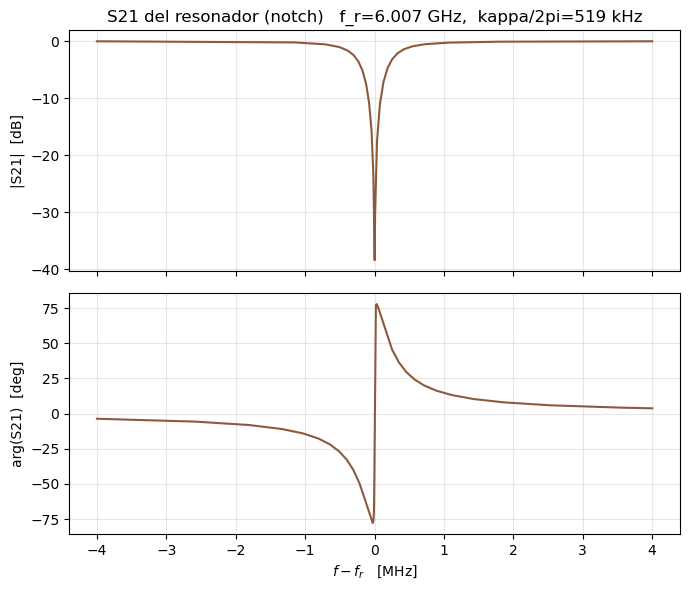

In [101]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Resonador notch (side-coupled) acoplado a la linea:
#   S21(w) = 1 - (k_ext/2) / ((k_ext+k_int)/2 + i (w - w_r))
Qi    = 1e6                              # Q interno (perdidas) -> profundidad finita del dip
w0    = 2*np.pi*fr*1e9                   # rad/s
k_ext = 2*np.pi*kappa_lw                 # rad/s  (acople externo, de la Celda 1)
k_int = w0/Qi                            # rad/s  (perdidas internas)

f   = np.linspace(fr-0.004, fr+0.004, 4000)         # GHz
S21 = 1 - (k_ext/2) / ((k_ext+k_int)/2 + 1j*(2*np.pi*f*1e9 - w0))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot((f-fr)*1e3, 20*np.log10(np.abs(S21)), color="#8c5a3b")
ax1.set_ylabel("|S21|  [dB]"); ax1.grid(alpha=.3)
ax1.set_title(f"S21 del resonador (notch)   f_r={fr} GHz,  kappa/2pi={kappa_lw/1e3:.0f} kHz")
ax2.plot((f-fr)*1e3, np.angle(S21, deg=True), color="#8c5a3b")
ax2.set_ylabel("arg(S21)  [deg]"); ax2.set_xlabel(r"$f - f_r$   [MHz]"); ax2.grid(alpha=.3)
fig.tight_layout(); plt.show()

## Simulación de los niveles de energia del sistema Fluxonium-Resonador

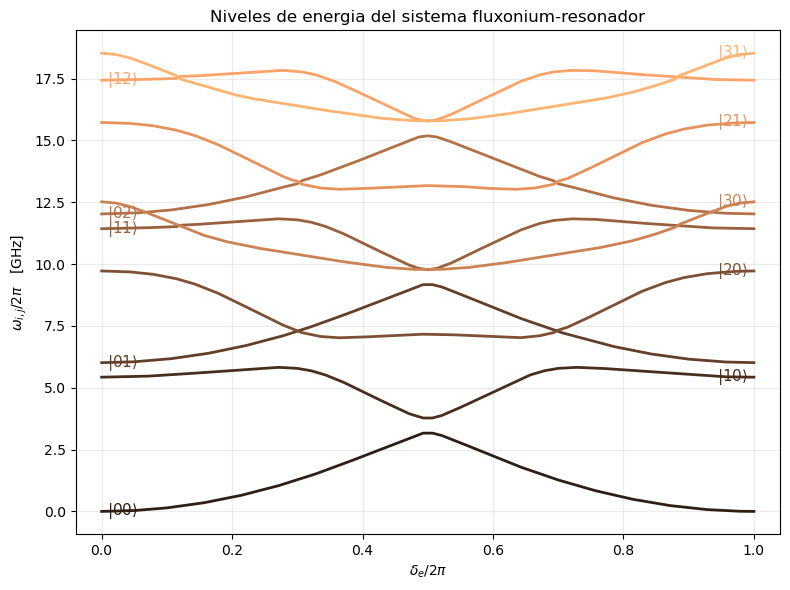

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scqubits as sq        # pip install scqubits

NQ, NR = 6, 5                # niveles del qubit / fotones del resonador
chars = [(0,0),(1,0),(0,1),(2,0),(1,1),(0,2),(3,0),(2,1),(1,2),(3,1)]   # estados a mostrar
flux_list = np.linspace(0, 1, 141)

a  = np.diag(np.sqrt(np.arange(1, NR)), 1); ad = a.T.conj()
Iq, Ir = np.eye(NQ), np.eye(NR)

# Energia de cada estado |i,j> (seguido por su caracter) vs flujo externo
energies = {c: [] for c in chars}; ref = None
for k, fx in enumerate(flux_list):
    fl  = sq.Fluxonium(EJ=EJ, EC=EC, EL=EL, flux=fx, cutoff=110)
    wq  = fl.eigenvals(evals_count=NQ)
    nm  = fl.matrixelement_table('n_operator', evals_count=NQ)
    H   = np.kron(np.diag(wq), Ir) + np.kron(Iq, fr*(ad@a)) + g_n*np.kron(nm, a+ad)
    E, V = np.linalg.eigh(H)
    if k == 0: ref = E[0]                          # referencia: E_00 en flux=0
    for (i, j) in chars:
        bare = np.zeros(NQ*NR); bare[i*NR + j] = 1
        energies[(i, j)].append(E[np.argmax(np.abs(V.conj().T @ bare))] - ref)

colors = plt.cm.copper(np.linspace(0.15, 0.9, len(chars)))
fig, ax = plt.subplots(figsize=(8, 6))
for c, col in zip(chars, colors):
    y = np.array(energies[c]); ax.plot(flux_list, y, color=col, lw=2)
    lab = rf"$|{c[0]}{c[1]}\rangle$"
    if c[0] <= c[1]:   # |0j>, |11>, |12> ... a la izquierda
        ax.annotate(lab, (0, y[0]),  xytext=(4, 0),  textcoords='offset points',
                    color=col, va='center', ha='left',  fontsize=11)
    else:              # |i0>, |21>, |31> ... a la derecha
        ax.annotate(lab, (1, y[-1]), xytext=(-4, 0), textcoords='offset points',
                    color=col, va='center', ha='right', fontsize=11)
ax.set_xlim(-0.04, 1.04)
ax.set_xlabel(r"$\delta_e/2\pi$"); ax.set_ylabel(r"$\omega_{i,j}/2\pi$   [GHz]")
ax.set_title("Niveles de energia del sistema fluxonium-resonador")
ax.grid(alpha=.25); fig.tight_layout(); plt.show()